In [2]:
#MODULE IMPORT
try:
    import math as my
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')

try :
    import warnings
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')

try:
    import pandas as pd
    print(f'Pandas {pd.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import numpy as np
    print(f'Numpy {np.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import xarray as xr
    print(f'Xarray {xr.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import matplotlib as mat
    import matplotlib.pyplot as plt
    print(f'Matplotlib {mat.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')

try:
    import calendar as cally
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')    

try:
    import time as time
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')

try:
    import scipy as sp
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    from datetime import timedelta
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
try:
    import regionmask as remy
    print(f'Regionmask {remy.__version__} loaded successfully')
except ImportError as e:
    print(f'{e}')
except ModuleNotFoundError as e:
    print(f'{e}')
    
import os
import sys
print('+++++++++++++++ \n MODULES READY \n+++++++++++++++')

Pandas 2.3.0 loaded successfully
Numpy 2.2.6 loaded successfully
Xarray 2025.7.0 loaded successfully
Matplotlib 3.10.3 loaded successfully
Regionmask 0.13.0 loaded successfully
+++++++++++++++ 
 MODULES READY 
+++++++++++++++


In [3]:
#SUPPORT CELL
model = input(f'Which model are you running? ')
mode = input(f'And which series are we in? ')
now = input(f"'Full' or 'NearFuture' or 'MidFuture' or 'FarFuture'? ")

filepath1 = f'/mnt/nrdstor/dixon/mudby97/FWI_test/vardata/cmip6/{mode}/tasmax/Downscaled_CMIP6_tasmax_Nebraska_{mode}_{model}.nc'
filepath2 = f'/mnt/nrdstor/dixon/mudby97/FWI_test/vardata/cmip6/{mode}/pr/Downscaled_CMIP6_pr_Nebraska_{mode}_{model}.nc'
filepath3 = f'/mnt/nrdstor/dixon/mudby97/FWI_test/vardata/cmip6/{mode}/hurs/Downscaled_CMIP6_hurs_Nebraska_{mode}_{model}.nc'   
tasfile = xr.open_dataset(filepath1)
prfile = xr.open_dataset(filepath2)
hurfile = xr.open_dataset(filepath3)

if mode == 'Historical' and now == 'Full':
    timestamp = range(1095,12045)
elif mode == 'ssp585' and now == 'Full':
    timestamp = range(4014, 31389)
elif mode == 'ssp585' and now == 'NearFuture':
    timestamp = range(4015,11315)
elif mode == 'ssp585' and now == 'MidFuture':
    timestamp = range(15330,26645)
elif mode == 'ssp585' and now == 'FarFuture':
    timestamp = range(26645,31389)
else:
    print('Invalid Time Frame')
    sys.exit()


T = tasfile['tasmax'].sel(
    time=tasfile['time'][timestamp],
    lat=tasfile['lat'],
    lon=tasfile['lon'])
RA = prfile['pr'].sel(
    time=prfile['time'][timestamp],
    lat=prfile['lat'],
    lon=prfile['lon'])
RH = hurfile['hurs'].sel(
    time=hurfile['time'][timestamp],
    lat=hurfile['lat'],
    lon=hurfile['lon'])

print(f'{len(timestamp)}')
print(f"{T.coords} \n {RA.coords} \n {RH.coords} \n+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+")
print(f"{RH.values}")

#BUILD A CONSTRAIN FUNCTION FOR BROKEN VALUES

Which model are you running? CESM2
And which series are we in? ssp585
'Full' or 'NearFuture' or 'MidFuture' or 'FarFuture'? NearFuture
7300
Coordinates:
  * lat      (lat) float64 96B 40.2 40.45 40.7 40.95 ... 42.2 42.45 42.7 42.95
  * lon      (lon) float64 288B 256.1 256.3 256.6 256.8 ... 264.3 264.6 264.8
  * time     (time) datetime64[ns] 58kB 2026-01-01 2026-01-02 ... 2045-12-31 
 Coordinates:
  * lat      (lat) float64 96B 40.2 40.45 40.7 40.95 ... 42.2 42.45 42.7 42.95
  * lon      (lon) float64 288B 256.1 256.3 256.6 256.8 ... 264.3 264.6 264.8
  * time     (time) datetime64[ns] 58kB 2026-01-01 2026-01-02 ... 2045-12-31 
 Coordinates:
  * lat      (lat) float64 96B 40.2 40.45 40.7 40.95 ... 42.2 42.45 42.7 42.95
  * lon      (lon) float64 288B 256.1 256.3 256.6 256.8 ... 264.3 264.6 264.8
  * time     (time) datetime64[ns] 58kB 2026-01-01 2026-01-02 ... 2045-12-31 
+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+
[[[-2.36925089e+33  1.93678764e+34 -5.8465

In [4]:
#DUFF MOISTURE CODE 
#DOCUMENTATION BY https://daac/ornl.gov/CMS/guides/CMS_Fire_Weather_Data_AH.html INDICATES OPEN ENDED SCALE BUT TYPICALLY VALUES RANGE 0-150
#HIGHER VALUES INDICATE HIGHER FIRE DANGER 


dufflength = {
        1: 6.5, #JAN
        2: 7.5, #FEB
        3: 9, #MAR
        4: 12.8, #APR
        5: 13.9, #MAY
        6: 13.9, #JUN
        7: 12.4, #JUL
        8: 10.9, #AUG
        9: 9.4, #SEP
        10: 8.0, #OCT
        11: 7.0, #NOV
        12: 6.0, #DEC
    }

def monthcall(step):
        try:
            month_call = step['time'].dt.month.item()
            month = month_call
            return month
        except Exception as e:
            month_call = 7
            month = month_call
            return month

def duff_mc(P1, precip, t, hurs, step, latitude, longitude): 
    #P1 is previous day moisture code, currently test value, RA = Precip value, T = Temperature, RH = Relative Humidity, dufflength = daylength for DMC values, month_call = figures month from the tas.nc
    # WHERE DO WE GET P1 FROM IN THE BEGINNING
    P0 = round(np.float64(P1),5)
    le_func = monthcall(step)                                     #MONTHCALL HAPPENS HERE
    Le = dufflength[le_func]
    T = t
    r0 = precip
    H = hurs
    e = my.e #EULERS NUMBER FOR MATH
    #print(f"{P0} was previous DMC")
    #print(f"{r0} is current precipitation")
    #print(f"{T} is current temperature")
    #print(f"{H} is current RH")
    
    ###NaN SQUEEZER PART DOS CATCHES PRIOR NaN AND IGNORES ###
    if P1 == 'NaN' :
        P1 = 6
    else : pass
    
    ###TESTS PRECIPITATION IN THE EVENT OF INCLEMENT WEATHER ###
    if r0 > 1.5:
        #print(f"Precip Vehicle triggered")
        re = (0.92 * r0) - 1.27
        try :
            stepone = (P0/43.43)
            rounded_one = round(np.float32(stepone),5)
            #print(f"Step one is {rounded_one}")
            steptwo = 5.6348 - rounded_one
            rounded_two = round(np.float32(steptwo),5)
            #print(f"Step two is {rounded_two}")
            stepthree = np.exp(rounded_two) #EULERS NUMBER USED HERE
            stepfour = np.float32(stepthree)
            stepfive = 20 + stepfour
            M0 = np.float32(stepfive)
            # this is our end result for this chain M0 = 20 + ((e)**(5.6348-(P0/43.43)))
        except Exception as welldarn :
            #print(f'{welldarn}', '\n', 'P0 was ', P0, '\n', 'precipation was ', r0,)
            sys.exit()
        if P0 <= 33:
                   b = 100/(0.5+(0.3*P0))
        elif 33 < P0 <= 65:
            b =  14 -(1.3 * (my.log(P0)))
        else : # P0 > 65:
            b = (6.2 * (my.log(P0)))-17.2
        #else: pass
        #print(f'B is {b}')
        Mr = M0 + ((1000 * re) / (48.77 + (b * re)))
        #print(f'Mr is {Mr}')
        Pr = 244.72 - 43.43 * my.log(Mr - 20)
        #print(f'Pr is {Pr}')
        if Pr <= 0: #Pr CANNOT BE NEGATIVE
            Pr = 0
        else: pass
        P0 = Pr # REPLACING VEHICLE WITH PRECIP VALUE
        #print(f"{P0} replacing precip")
    else: pass 
    ###END OF PRECIP TEST###
    
    
    if T <= -1.1 : #NEGATIVE TEMPS GET SET TO 0
        T = -1.1
    else: pass
    
    
    K = 1.894*(T + 1.1)*(100 - H)*(Le * ((10)**(-6)))   #H IS HUMIDITY
    #print(f"K is {K}")
    P = P0 + (100 * K)
    #print(f"P is {P}")
    DMC = P
    #global P1
    P1 = f'{P:.5f}'
    #print(f'Success P1 was {P1}')
    return(DMC) # GIVES US THE DUFF MOISTURE CODE FOR TODAY    
    #return(P1) #INSERTS THE DMC INTO THE PREVIOUS-DAY VALUE FOR THE NEXT CALC

def spaceloop(t, precip, hurs, P1):
    startcheck = time.perf_counter()
    rmc = xr.full_like(t, fill_value=np.nan)
    for lat_idx in range(t.shape[1]):
                for lon_idx in range(t.shape[2]):
                    t_now = t.isel(lat=lat_idx, lon=lon_idx)
                    precip_now = precip.isel(lat=lat_idx, lon=lon_idx)
                    hurs_now = hurs.isel(lat=lat_idx, lon=lon_idx)
                    for time_idx in range(t_now.sizes['time']):
                        timestep = t_now.isel(time=time_idx)
                        r0_val = precip_now.values[time_idx]
                        t_val = t_now.values[time_idx]
                        h_val = hurs_now.values[time_idx]
                        if h_val >= 0 and h_val <= 105 :
                            RMC = duff_mc(P1, r0_val, t_val, h_val, timestep, lat_idx, lon_idx) #DUFF MC CALLED HERE
                            P1 = RMC
                        else : 
                            RMC = P1
                            P1 = P1
                        rmc.loc[dict(lat=t_now.lat.values, lon=t_now.lon.values, time=t_now.time.values)] = RMC
                checktime = timedelta(seconds=time.perf_counter() - startcheck)
                print(f'Checkpoint {lat_idx} at {checktime}')
    frmc = rmc.rename('duff')
    frmc.attrs["units"] = 'dmc'
    return frmc

start_time = time.perf_counter()
print(f"Beginning Duff Calc for {model}'s {now} {mode} data")

warnings.filterwarnings("error")
    
testrun = spaceloop(T, RA, RH, 6) #DOCUMENTATION STATES SPIN UPS BEGIN WITH DMC SET TO 6
try:
    testrun.to_netcdf(f'Nebraska_{now}_{mode}_{model}_DUFF_TUNNELED1_.nc')
    print(f"Successfully saved as 'Nebraska_{now}_{mode}_{model}_DUFF_TUNNELED1.nc'!")
except Exception as oops:
    print(f'Uh oh. \n{oops}')
loop_time = timedelta(seconds=time.perf_counter() - start_time)
print(f"This took us about {loop_time}")

#RANGE IS OPEN ENDED

Beginning Duff Calc for CESM2's NearFuture ssp585 data
Checkpoint 0 at 0:05:06.476172
Checkpoint 1 at 0:10:15.074078
Checkpoint 2 at 0:15:36.001560
Checkpoint 3 at 0:20:51.507517
Checkpoint 4 at 0:26:05.707100
Checkpoint 5 at 0:31:19.205110
Checkpoint 6 at 0:36:31.972833
Checkpoint 7 at 0:41:48.379228
Checkpoint 8 at 0:46:50.867068
Checkpoint 9 at 0:51:56.393479
Checkpoint 10 at 0:57:01.139735
Checkpoint 11 at 1:02:05.764000
Successfully saved as 'Nebraska_NearFuture_ssp585_CESM2_DUFF_TUNNELED1.nc'!
This took us about 1:02:06.069142


This took us about 0:00:00.005233
<xarray.DataArray 'duff' (lat: 12, lon: 36)> Size: 2kB
array([[17.750122  , 14.755918  , 12.9427395 , 31.7971    , 28.698298  ,
        35.234623  , 38.885876  , 33.282093  , 36.954338  , 29.371403  ,
        25.770727  , 34.92167   , 23.704536  , 31.909819  , 26.282501  ,
        29.640343  , 23.916302  , 20.225334  , 25.43645   , 20.718407  ,
        19.139143  , 12.885491  , 12.528451  ,  9.186784  ,  8.758061  ,
         4.8945045 ,  2.062554  ,  1.0044973 ,  1.6852838 ,  1.5338895 ,
         0.82959193,  0.        ,  0.37011683,  0.1757447 ,  1.4446429 ,
         0.        ],
       [32.35939   , 20.05561   , 18.045319  , 35.706306  , 37.480034  ,
        26.760689  , 43.637238  , 34.95614   , 41.916927  , 40.70108   ,
        30.250006  , 24.845095  , 28.15623   , 37.906956  , 26.984379  ,
        19.775597  , 19.349188  , 22.52156   , 24.995773  , 15.2896    ,
        20.610672  , 13.114649  ,  8.183862  ,  8.292953  , 12.924421  ,
         7.75

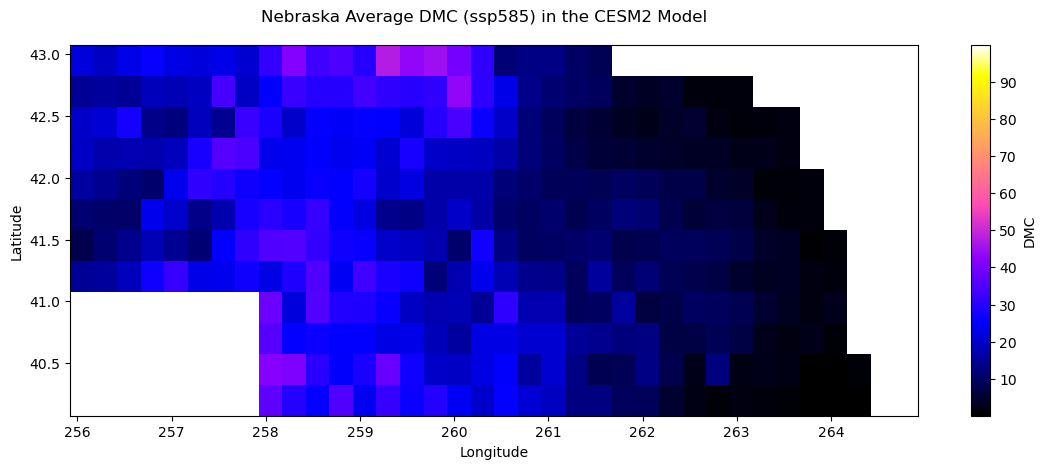

This took us about 0:00:00.263983


In [7]:
start_average = time.perf_counter()    
averagedata = testrun.mean(dim = 'time') #PANDAS IGNORES NAN AUTOMATICALLY
averagetimer = timedelta(seconds=time.perf_counter() - start_average)
print(f'This took us about {averagetimer}')
print(averagedata)

states = remy.defined_regions.natural_earth_v5_0_0.us_states_10  #DONT TOUCH! THE STATES_50 DOESNT WORK AND WILL BREAK IT 
mask = states.mask(averagedata)
neb_idx = states.names.index('Nebraska')
nebraska_masked = averagedata.where(mask == neb_idx)

start_ploat = time.perf_counter()
im = nebraska_masked.plot(figsize=(11.5,4.74), cmap='gnuplot2', robust=False, add_colorbar=False, vmin=0, vmax=100)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.suptitle(f'Nebraska Average DMC ({mode}) in the {model} Model', x=0.425)

plt.colorbar(im, label='DMC', orientation='vertical', ticks=[10, 20, 30, 40, 50, 60, 70, 80, 90])

plt.tight_layout()
#plt.savefig(f"Nebraska_Avg_{series}_{process}_{now}.png", dpi=600, bbox_inches='tight')
plt.show()
plottimer = timedelta(seconds=time.perf_counter() - start_ploat)
print(f'This took us about {plottimer}')

save successful


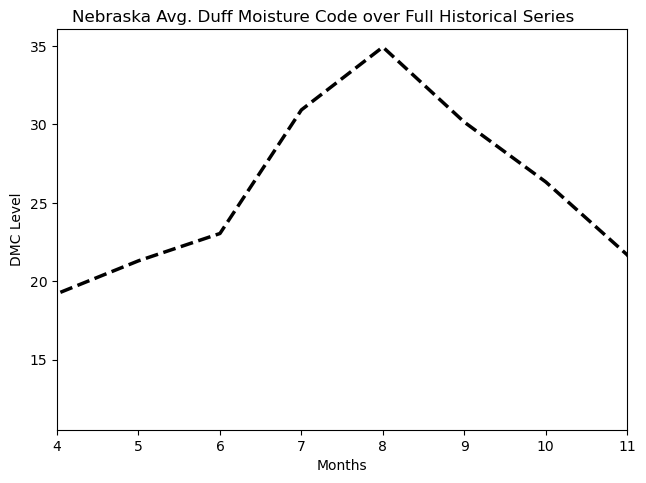

In [27]:
timerun = testrun.groupby('time.month').mean('time')
finalrun = timerun.mean(dim=['lat', 'lon'])

finalrun.plot.line(label='Overall Average', x=None, color='black', linewidth=2.5, linestyle='--', alpha=1)
plt.suptitle(f'Nebraska Avg. Duff Moisture Code over {now} {mode} Series')
plt.xlim(4,11)
plt.xlabel('Months')
plt.ylabel('DMC Level')
plt.tight_layout(pad=0.5)
try:
    plt.savefig(f'Nebraska_EXAMPLE_duff')
    plt.show
    print('save successful')
except Exception as oopsie:
    print(f'{oopsie}')